# EDA and Charts
This notebook focuses on the analysis of the final dataset, specifically on explaining outliers, on displaying charts, and on setting up the downstream operation of data visualization.


In [2]:
import pandas as pd
from pathlib import Path

# Load the dataframe
path = Path("../data/2_final.csv")
df = pd.read_csv(path,
    dtype={"REF_AREA": str, "PROVINCE": str},
    keep_default_na=False # This is to prevent automatic conversion of None and NA into empty fields
)

print("Dataframe loaded.")

Dataframe loaded.


## STEP 1. Temporal trends
After loading the final dataset, it's possible to analyse the multi-year trends across Italy for accidents, injuries, and deaths in order to identify macro-trends over the last decade.

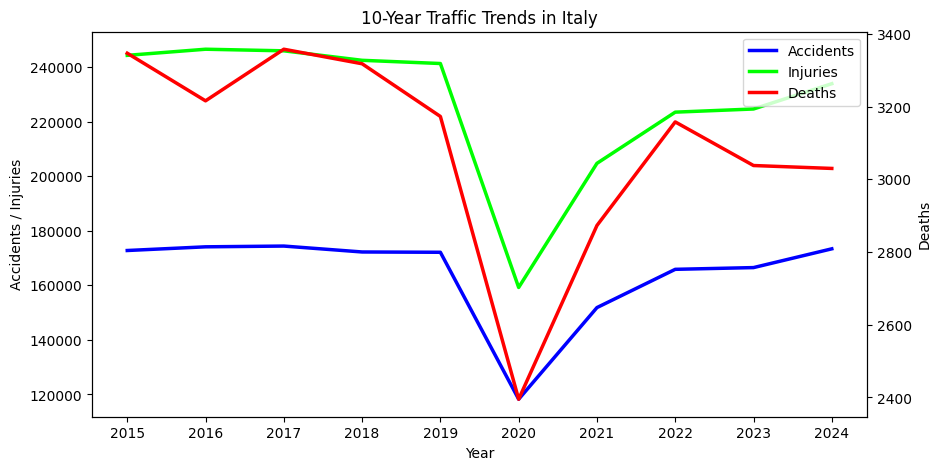

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aggregate yearly totals across all municipalities for the last 10 years
yearly_trends = (
    df.groupby("TIME_PERIOD")[["ACCIDENTS", "INJURIES", "DEATHS"]].sum().reset_index().sort_values("TIME_PERIOD").tail(10)
)

# Plot the data
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Accidents & Injuries
ax1.plot(yearly_trends["TIME_PERIOD"], yearly_trends["ACCIDENTS"], 
         color="#0000ff", linewidth=2.5, label="Accidents")
ax1.plot(yearly_trends["TIME_PERIOD"], yearly_trends["INJURIES"], 
         color="#00ff00", linewidth=2.5, label="Injuries")

ax1.set_xlabel("Year")
ax1.set_ylabel("Accidents / Injuries")
ax1.set_xticks(yearly_trends["TIME_PERIOD"])

# Secondary Axis: Deaths (scaled separately as the number is too small)
ax2 = ax1.twinx()
ax2.plot(yearly_trends["TIME_PERIOD"], yearly_trends["DEATHS"], 
         color="#ff0000", linewidth=2.5, label="Deaths")
ax2.set_ylabel("Deaths")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("10-Year Traffic Trends in Italy")
plt.show()

Across the 10-year span, accidents and injuries display an almost-parallel relationship, whereas the number of deaths is much more volatile.

By looking at the graph, it's impossible not to notice che drastic drop of accidents, deaths and injuries in 2020 and, albeit less noticeably, in 2021, followed by a return to normal counts in the following years. This drastic drop coincides with the 2020 COVID-19 lockdown, which created an artificial downward deviation due to nationwide mobility restrictions.

This means that including the raw 2020 data without adjustments might severely distort regression models and lead to inaccurate predictions; this means that 2020 data should be either excluded or estimated based on previous data, as it represents an anomaly.

## STEP 2. Handling distortion caused by population differences
When analyzing risk ratios per 1.000 inhabitants, comparing municipalities with different population sizes causes analytical distortion:
1. in smaller cities, a single major crash may increase the rate to extreme values (e.g. 15 accidents in a village of 300 inhabitants yields a rate of 50 accidents per 1.000$ inhabitants), which ranks these tiny cities higher in risk than metropolitan centers;
2. conversely, the higher number of residents in large metropolitan centers (like Rome and Milan) dilutes the pro capite rate despite having thousands of crashes.

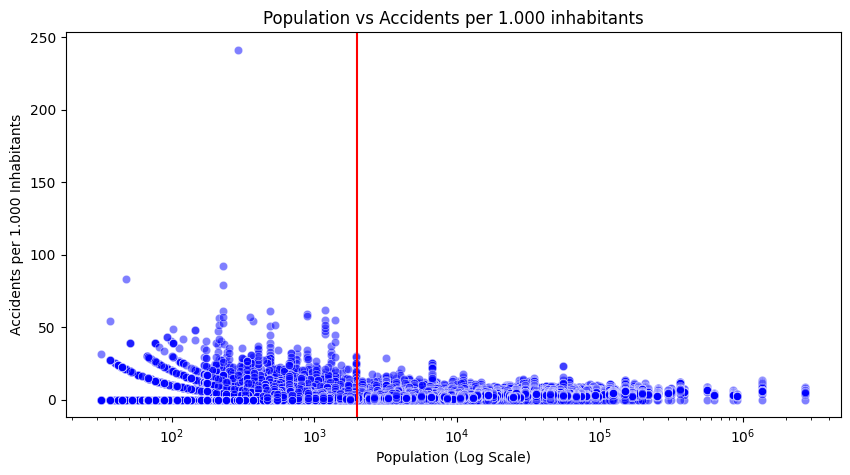

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df, 
    x="POPULATION", 
    y="ACCIDENTS_PER_1000_INH", 
    alpha=0.5, 
    color="#0000ff"
)

plt.xscale('log')
plt.axvline(x=2000, color="#ff0000")

plt.title("Population vs Accidents per 1.000 inhabitants")
plt.xlabel("Population (Log Scale)")
plt.ylabel("Accidents per 1.000 Inhabitants")
plt.show()

From the graph, it's clear that the data points for smaller cities are distributed more erratically across the vertical axis, especially for cities with less than  2.000 inhabitants (the red line), whereas for cities above 2.000 inhabitants the graph settles into a narrower horizontal distribution.

Since a single accident in a small town risks shifting the pro capite rate more dramatically than a single accident in a big city, including them in the data pool might corrupt the data with noise and yield analytical results that do not reflect the reality of traffic danger.